In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

In [4]:
import pandas as pd

actual_df = pd.read_json("actual.json")
forecast_df = pd.read_json("forecast.json")

print(actual_df.head())
print(forecast_df.head())

  dataset           publishTime             startTime settlementDate  \
0  FUELHH  2026-03-14T07:00:00Z  2026-03-14T06:30:00Z     2026-03-14   
1  FUELHH  2026-03-14T06:30:00Z  2026-03-14T06:00:00Z     2026-03-14   
2  FUELHH  2026-03-14T06:00:00Z  2026-03-14T05:30:00Z     2026-03-14   
3  FUELHH  2026-03-14T05:30:00Z  2026-03-14T05:00:00Z     2026-03-14   
4  FUELHH  2026-03-14T05:00:00Z  2026-03-14T04:30:00Z     2026-03-14   

   settlementPeriod fuelType  generation  
0                14     WIND        6708  
1                13     WIND        6595  
2                12     WIND        6525  
3                11     WIND        6424  
4                10     WIND        6903  
   dataset           publishTime             startTime  generation
0  WINDFOR  2026-03-14T04:30:00Z  2026-03-13T21:00:00Z       11988
1  WINDFOR  2026-03-14T04:30:00Z  2026-03-13T22:00:00Z       10360
2  WINDFOR  2026-03-14T04:30:00Z  2026-03-13T23:00:00Z        9447
3  WINDFOR  2026-03-14T04:30:00Z  2026-03

In [5]:
actual_df["startTime"] = pd.to_datetime(actual_df["startTime"])
forecast_df["startTime"] = pd.to_datetime(forecast_df["startTime"])
forecast_df["publishTime"] = pd.to_datetime(forecast_df["publishTime"])

print(actual_df.head())
print(forecast_df.head())

  dataset           publishTime                 startTime settlementDate  \
0  FUELHH  2026-03-14T07:00:00Z 2026-03-14 06:30:00+00:00     2026-03-14   
1  FUELHH  2026-03-14T06:30:00Z 2026-03-14 06:00:00+00:00     2026-03-14   
2  FUELHH  2026-03-14T06:00:00Z 2026-03-14 05:30:00+00:00     2026-03-14   
3  FUELHH  2026-03-14T05:30:00Z 2026-03-14 05:00:00+00:00     2026-03-14   
4  FUELHH  2026-03-14T05:00:00Z 2026-03-14 04:30:00+00:00     2026-03-14   

   settlementPeriod fuelType  generation  
0                14     WIND        6708  
1                13     WIND        6595  
2                12     WIND        6525  
3                11     WIND        6424  
4                10     WIND        6903  
   dataset               publishTime                 startTime  generation
0  WINDFOR 2026-03-14 04:30:00+00:00 2026-03-13 21:00:00+00:00       11988
1  WINDFOR 2026-03-14 04:30:00+00:00 2026-03-13 22:00:00+00:00       10360
2  WINDFOR 2026-03-14 04:30:00+00:00 2026-03-13 23:00:00+00:

In [6]:
merged = pd.merge(
    actual_df,
    forecast_df,
    on="startTime",
    suffixes=("_actual", "_forecast")
)

merged = merged[["startTime","generation_actual","generation_forecast"]]

merged.head()

,startTime,generation_actual,generation_forecast
0,2026-03-14 06:00:00+00:00,6595,7234
1,2026-03-14 05:00:00+00:00,6424,7963
2,2026-03-14 04:00:00+00:00,7055,8715
3,2026-03-14 03:00:00+00:00,6769,9063
4,2026-03-14 02:00:00+00:00,7236,9659


In [7]:
merged["error"] = merged["generation_forecast"] - merged["generation_actual"]
merged["abs_error"] = merged["error"].abs()

merged.head()

,startTime,generation_actual,generation_forecast,error,abs_error
0,2026-03-14 06:00:00+00:00,6595,7234,639,639
1,2026-03-14 05:00:00+00:00,6424,7963,1539,1539
2,2026-03-14 04:00:00+00:00,7055,8715,1660,1660
3,2026-03-14 03:00:00+00:00,6769,9063,2294,2294
4,2026-03-14 02:00:00+00:00,7236,9659,2423,2423


In [8]:
mean_error = merged["error"].mean()
median_error = merged["error"].median()
p99_error = merged["abs_error"].quantile(0.99)

print("Mean Error:", mean_error)
print("Median Error:", median_error)
print("P99 Error:", p99_error)

Mean Error: 1638.142857142857
Median Error: 1539.0
P99 Error: 2415.2599999999998


In [9]:
merged["horizon_hours"] = (
    forecast_df["startTime"] - forecast_df["publishTime"]
).dt.total_seconds() / 3600

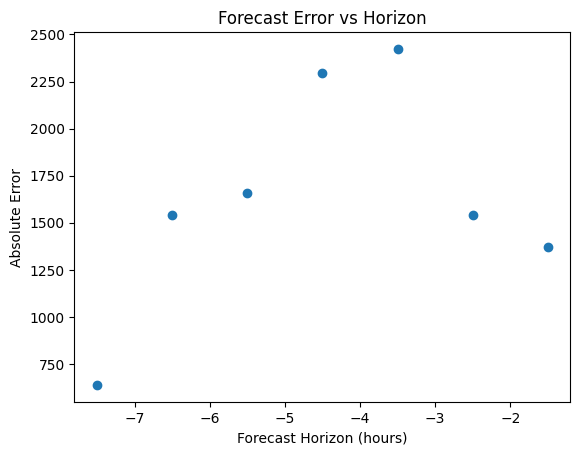

In [10]:
import matplotlib.pyplot as plt

plt.scatter(merged["horizon_hours"], merged["abs_error"])

plt.xlabel("Forecast Horizon (hours)")
plt.ylabel("Absolute Error")
plt.title("Forecast Error vs Horizon")

plt.show()

In [11]:
p10 = actual_df["generation"].quantile(0.10)
p25 = actual_df["generation"].quantile(0.25)
p50 = actual_df["generation"].quantile(0.50)

print("10th percentile:", p10)
print("25th percentile:", p25)
print("Median:", p50)

10th percentile: 6546.0
25th percentile: 6708.0
Median: 6968.5
